# [Disasters on Social Media (DSM)](https://data.world/crowdflower/disasters-on-social-media)

Contributors looked at over 10,000 tweets culled with a variety of searches like "ablaze", "quarantine", and "pandemonium", then noted whether the tweet referred to a disaster event (as opposed to a joke with the word or a movie review or something non-disastrous). Added: September 4, 2015 by CrowdFlower

Data Rows: 10877

---

## A. Original description

## B. Overview

In [1]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
dataset_path = (
    Path(os.getenv("DATASETS_PATH"))
    / "Disasters_on_Social_Media"
    / "socialmedia-disaster-tweets-DFE.csv"
)

df = pd.read_csv(dataset_path, encoding="latin-1")
# df.columns = df.columns.str.strip()

df.head()

,_unit_id,_golden,_unit_state,_trusted_judgments,_last_judgment_at,choose_one,choose_one:confidence,choose_one_gold,keyword,location,text,tweetid,userid
0,778243823,True,golden,156,NaN,Relevant,1.0000,Relevant,NaN,NaN,Just happened a terrible car crash,1.0,NaN
1,778243824,True,golden,152,NaN,Relevant,1.0000,Relevant,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,13.0,NaN
2,778243825,True,golden,137,NaN,Relevant,1.0000,Relevant,NaN,NaN,"Heard about #earthquake is different cities, s...",14.0,NaN
3,778243826,True,golden,136,NaN,Relevant,0.9603,Relevant,NaN,NaN,"there is a forest fire at spot pond, geese are...",15.0,NaN
4,778243827,True,golden,138,NaN,Relevant,1.0000,Relevant,NaN,NaN,Forest fire near La Ronge Sask. Canada,16.0,NaN


In [3]:
# Drop golden data, which is used for evaluation and should not be included in training or analysis.
df.drop(df[df["_golden"] == True].index, inplace=True)

import random

# generate tweet_id randomly since the original dataset does not have a unique identifier
# Set the seed to any integer (e.g., 42)
random.seed(42)
df["tweet_id"] = [
    random.randint(9000000000000000000, 9999999999999999999) for _ in range(len(df))
]

df["informative"] = df["choose_one"].apply(lambda x: True if x == "Relevant" else False)
df["event_type"] = 'disaster'
df["event_name"] = np.nan
df["year"] = np.nan
df["dataset"] = "disasters_on_social_media"
df["meta"] = {"tweet_id": "randonly_generated"}
df['humanitarian_label'] = np.nan
df.rename(columns={"text": "tweet_text"}, inplace=True)

df.drop_duplicates(subset=["tweet_text"], inplace=True)

df = df[
    [
        "tweet_id",
        "tweet_text",
        "informative",
        "event_type",
        "event_name",
        "year",
        "dataset",
        "meta"
    ]
]
df.head()

,tweet_id,tweet_text,informative,event_type,event_name,year,dataset,meta
46,9128355989445507485,Birmingham Wholesale Market is ablaze BBC News...,True,disaster,NaN,NaN,disasters_on_social_media,NaN
47,9854949519964969681,@sunkxssedharry will you wear shorts for race ...,False,disaster,NaN,NaN,disasters_on_social_media,NaN
48,9282341088111907415,@bbcmtd Wholesale Markets ablaze http://t.co/l...,True,disaster,NaN,NaN,disasters_on_social_media,NaN
49,9160876273137374942,We always try to bring the heavy. #metal #RT h...,False,disaster,NaN,NaN,disasters_on_social_media,NaN
50,9118168890076913833,#AFRICANBAZE: Breaking news:Nigeria flag set a...,True,disaster,NaN,NaN,disasters_on_social_media,NaN


<Axes: xlabel='informative'>

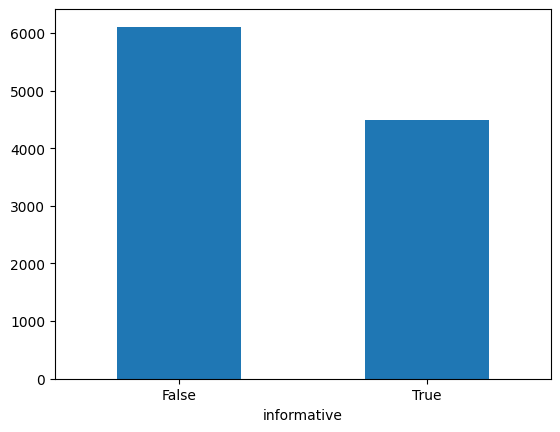

In [4]:
df['informative'].value_counts().plot(kind='bar', rot=0)

In [5]:
df['event_type'].value_counts()

event_type
disaster    10603
Name: count, dtype: int64

In [6]:
import csv
df.to_csv( '../data/datasets/DSM.csv', index=False, quoting=csv.QUOTE_ALL)